### Introduction
This notebook applies a SARIMAX model to forecast Alberta Internal Load (AIL).

<class 'pandas.Series'>
DatetimeIndex: 1096 entries, 2023-01-01 to 2025-12-31
Freq: D
Series name: Actual AIL
Non-Null Count  Dtype
--------------  -----
1096 non-null   int64
dtypes: int64(1)
memory usage: 17.1 KB
None
Date
2023-01-01    239332
2023-01-02    244686
2023-01-03    251469
2023-01-04    253158
2023-01-05    253619
Freq: D, Name: Actual AIL, dtype: int64


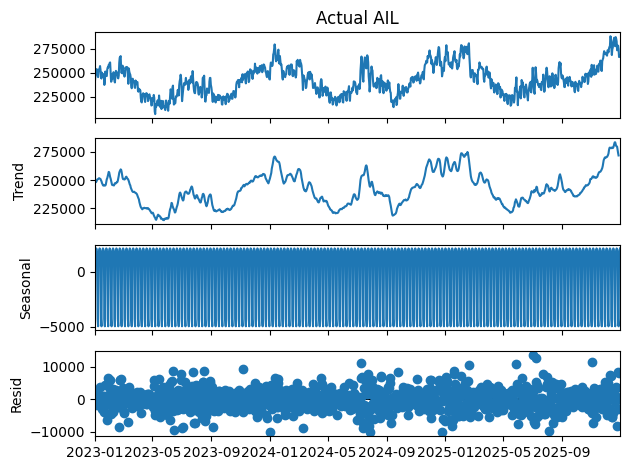

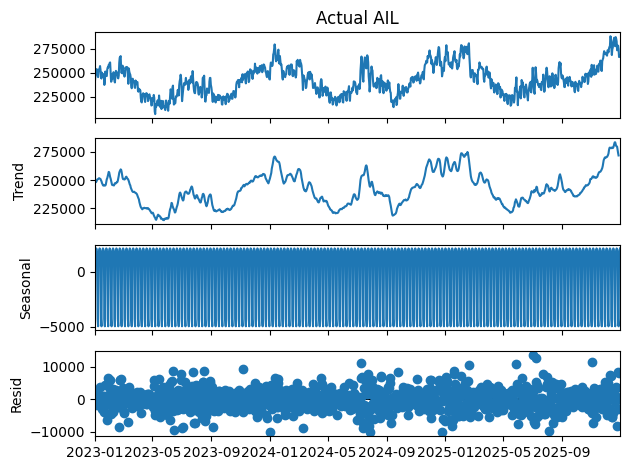

In [39]:
# Demand forecast
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

################### Load Data #####################################
df = pd.read_csv('2023ActualForecastData.csv')
df1 = pd.read_csv('2024ActualForecastData.csv')
df2 = pd.read_csv('2025ActualForecastData.csv')
AIL = pd.concat([df, df1, df2])
AIL['Date'] = pd.to_datetime(AIL['Date'])
AIL_indexed = AIL.set_index('Date')
daily_sum = AIL_indexed['Actual AIL'].resample('D').sum()
daily_count = AIL_indexed['Actual AIL'].resample('D').count()
# Keep only weeks with the typical (modal) number of observations

# Create time series.
# Keep weeks within ±1 hour of full (handles DST: 167 and 169 are both valid)
# Keep only days with full observations (handles DST: 23 or 25 hours)
full_day = daily_count.mode()[0]  # typically 24
demand_data = daily_sum[(daily_count >= full_day - 1) & (daily_count <= full_day + 1)]
print(demand_data.info())
print(demand_data.head())


# Decompose time series into trend, seasonal and residual component
result = seasonal_decompose(demand_data, model='additive', period=7)
result.plot()


#### Stationary Check (ADF test)
ADF tests the null hypothesis that there is the existence of a unit root in the time series sample.
The presence of a unit root implies that the time series is non-stationary, that is,
its statistical properties such as mean and variance change over time and the series
follows a stochastic trend rather than reverting to a fixed mean.

In [56]:
def adftest(dataset):
    try:
        result = adfuller(dataset, autolag='AIC')
        print(f'ADF Statistic: {result[0]:.4f}')
        print(f'p-value: {result[1]:.4f}')
        print(f'Lags used: {result[2]}')
        print(f'Critical values: {result[4]}')
        if result[1] < 0.05:
            print('Time Series is Stationary')
        else:
            print('Fail to reject null hypothesis. Time Series is Non-Stationary')
    except Exception as e:
        print(f'Invalid dataset: {e}')

adftest(demand_data)

ADF Statistic: -2.4113
p-value: 0.1386
Lags used: 21
Critical values: {'1%': np.float64(-3.4364533503600962), '5%': np.float64(-2.864234857527328), '10%': np.float64(-2.568204837482531)}
Fail to reject null hypothesis. Time Series is Non-Stationary


#### Differencing
Differencing is a method used to transform a non-stationary time series by calculating
the difference between consecutive observations.

$$y'_t = y_t - y_{t-1}$$

It stabilizes the mean of a time series by removing changes in level and trend,
making it more suitable for modelling.

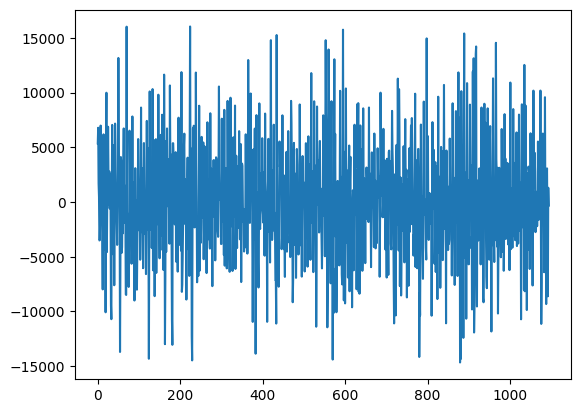

In [57]:
def adftest(dataset):
    try:
        result = adfuller(dataset, autolag='AIC')
        return result[1] < 0.05  # return True if stationary
    except Exception as e:
        print(f'Invalid dataset: {e}')
        return None

def difference(dataset, interval=1):
    if adftest(dataset):  # if stationary, skip
        print('Time Series is already stationary, no differencing needed')
        return dataset
    diff = []
    for i in range(interval, len(dataset)):
        diff.append(dataset.iloc[i] - dataset.iloc[i - interval])
    return pd.Series(diff)

difference(demand_data).plot()
plt.show()

#### Model Parameters
**Autocorrelation function (ACF):** Measures the correlation between the past values (lagged values) and the current value, including indirect effects. We will use the ACF to find Moving Average parameter q.

**Partial Autocorrelation function (PACF):** Measures the direct correlation between the k-th lagged value and the current value, removing indirect effects. We will use the PACF to find the Autoregressive parameter p.

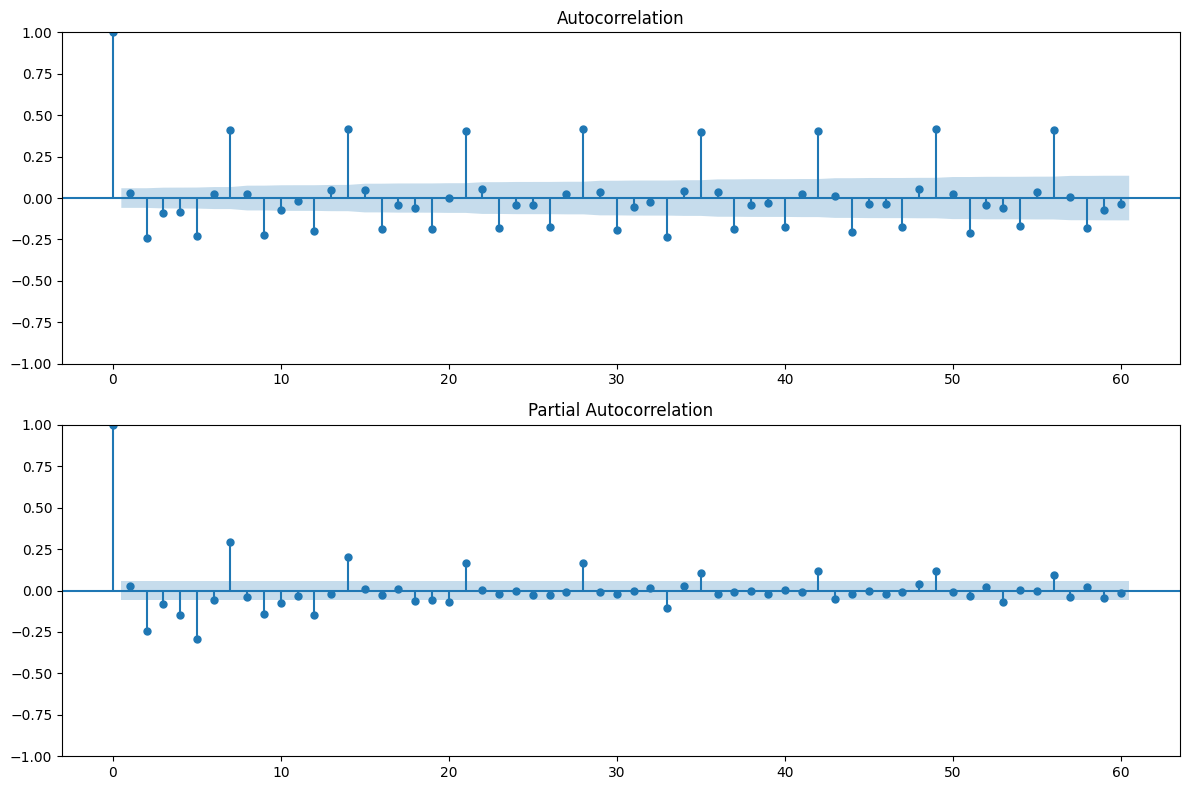

In [58]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(difference(demand_data,1), ax=ax[0], lags=60)   # ~2 months of days
plot_pacf(difference(demand_data,1), ax=ax[1], lags=60)

plt.tight_layout()
plt.show()

### SARIMAX Model

In [65]:
import itertools
import warnings
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt


def sarima_grid_search(train, test, m=7, p=range(3), q=range(3), P=range(2), Q=range(2)):
    """
    Grid search SARIMA orders, fixing d=1 and D=1 (known from the trend/seasonal
    decomposition). Models are ranked by forecast RMSE on the test set, with
    coefficient significance reported as a diagnostic rather than a sort key.
    """
    rows = []

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for pp, qq, PP, QQ in itertools.product(p, q, P, Q):
            order = (pp, 1, qq)
            seasonal_order = (PP, 1, QQ, m)
            try:
                fit = SARIMAX(train,
                              order=order,
                              seasonal_order=seasonal_order).fit(disp=False, maxiter=50).fit(disp=False, maxiter=100)

                rmse = np.sqrt(mean_squared_error(test, fit.forecast(len(test))))
                pvals = fit.pvalues.drop('sigma2', errors='ignore')

                rows.append({
                    'order': order,
                    'seasonal_order': seasonal_order,
                    'RMSE': rmse,
                    'AIC': fit.aic,
                    'all_significant': bool((pvals < 0.05).all()),
                })
            except Exception:
                continue

    return pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)


# Split (85/15) and set daily frequency
split = int(len(demand_data) * 0.85)
train = demand_data[:split].asfreq('D')
test = demand_data[split:].asfreq('D')

# Search
results = sarima_grid_search(train, test)
print(results.head(10))

'''
# Fit best model
best = results.iloc[0]
fit = SARIMAX(train,
              order=best['order'],
              seasonal_order=best['seasonal_order']).fit(disp=False)
print(fit.summary())

forecast = fit.forecast(len(test))
forecast.index = test.index

# Plot last 90 days of train + forecast vs actual
plt.figure(figsize=(15, 6))
plt.plot(train.index[-90:], train.values[-90:], 'b-', alpha=0.6, label='Train')
plt.plot(test.index, test.values, 'g-', lw=2, label='Actual')
plt.plot(forecast.index, forecast.values, 'r--', lw=2, label='Forecast')
plt.axvline(train.index[-1], color='black', ls=':', lw=2)
plt.legend(); plt.title('Split Forecast'); plt.grid(True); plt.show()

print(f"\nMAE:  {mean_absolute_error(test, forecast):,.0f} MWh")
print(f"RMSE: {np.sqrt(mean_squared_error(test, forecast)):,.0f} MWh")

'''

KeyError: 'RMSE'

### Conclusion
This SARIMAX model can only capture one seasonal period at a time, that is, it cannot simultaneously model the daily, weekly, and annual cycles present in the AIL data. Moreover, the 3-year dataset is insufficient for reliable SARIMAX modelling at any frequency. Monthly (s=12) performed best out of the frequencies tested. With only 28 training observations, the seasonal parameters are insignificant as shown in the results table. Adding more could potentially improve this model's performance. Weekly (s=52) and daily (s=365) are computationally expensive, but do not necessarily perform better.

Not good for a long term horizon